# Сборный проект-4

Вам поручено разработать демонстрационную версию поиска изображений по запросу.

Для демонстрационной версии нужно обучить модель, которая получит векторное представление изображения, векторное представление текста, а на выходе выдаст число от 0 до 1 — покажет, насколько текст и картинка подходят друг другу.

### Описание данных

Данные доступны по [ссылке](https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip).

В файле `train_dataset.csv` находится информация, необходимая для обучения: имя файла изображения, идентификатор описания и текст описания. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `train_images` содержатся изображения для тренировки модели.

В файле `CrowdAnnotations.tsv` — данные по соответствию изображения и описания, полученные с помощью краудсорсинга. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.
3. Доля людей, подтвердивших, что описание соответствует изображению.
4. Количество человек, подтвердивших, что описание соответствует изображению.
5. Количество человек, подтвердивших, что описание не соответствует изображению.

В файле `ExpertAnnotations.tsv` содержатся данные по соответствию изображения и описания, полученные в результате опроса экспертов. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.

3, 4, 5 — оценки трёх экспертов.

Эксперты ставят оценки по шкале от 1 до 4, где 1 — изображение и запрос совершенно не соответствуют друг другу, 2 — запрос содержит элементы описания изображения, но в целом запрос тексту не соответствует, 3 — запрос и текст соответствуют с точностью до некоторых деталей, 4 — запрос и текст соответствуют полностью.

В файле `test_queries.csv` находится информация, необходимая для тестирования: идентификатор запроса, текст запроса и релевантное изображение. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `test_images` содержатся изображения для тестирования модели.

## Скачаем данные для задания

In [ ]:
%pwd

'/content'

In [ ]:
DATA_PATH = './temp_data/datasets'
DATA_PATH

'./temp_data/datasets'

In [ ]:
# 0. Удалим директорию
!rm -rf {DATA_PATH}

# 1. Создать директорию
!mkdir -p {DATA_PATH}

# 2. Скачать архив
!curl -L -o {DATA_PATH}/data.zip "https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip"

# 3. Распаковать только папку to_upload
!unzip -q {DATA_PATH}/data.zip "to_upload/*" -d {DATA_PATH}
!mv {DATA_PATH}/to_upload/* {DATA_PATH}/

# 4. Удалить архив (опционально)
!rm -rf {DATA_PATH}/to_upload
!rm -rf {DATA_PATH}/test_images/.DS_Store
!rm {DATA_PATH}/data.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  143M  100  143M    0     0  19.1M      0  0:00:07  0:00:07 --:--:-- 24.7M


## Настройка окружения

In [ ]:
# %pip install -Uq torch==1.14.*
# %pip install -Uq torchvision==0.15.*

# %pip install -Uq torch
# %pip install -Uq torchvision
# %pip install -Uq plotly
# %pip install -Uq nltk
# %pip install -Uq wordcloud
# %pip install -Uq transformers


### Импорты

In [ ]:
import logging
import math
import os
import random
import re
import string
import warnings
from collections import Counter
from pathlib import Path
from typing import Dict, Any, Optional
from typing import Union, List

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import plotly.express as px
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
from PIL import Image
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import Normalizer
from torch.utils.data import Dataset
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms
from transformers import BertModel, BertTokenizer
from wordcloud import WordCloud


### Настройки отображения

In [ ]:
# output settings
warnings.filterwarnings("ignore")

options = {
    "display.max_rows": None,
    "display.max_columns": None,
    "display.float_format": "{:,.2f}".format,
    "display.max_colwidth": None,
}

for option, value in options.items():
    pd.set_option(option, value)

logging.getLogger("transformers").setLevel(logging.ERROR)

### Глобальные константы

In [ ]:
RANDOM_STATE = 42

def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

### Функции

In [ ]:
def check_size(current_df: pd.DataFrame, original_df: pd.DataFrame):
    """
    Проверяет и выводит на экран размерность current_df относительно original_df.

    Параметры:
    :param current_df: Текущий датасет
    :param original_df: Оригинальный датасет
    :return:
    """
    print(f"Количество записей в оригинальном датасете: {len(original_df)}")
    print(f"Количество записей в текущем датасете: {len(current_df)}")
    print(f"Количество удаленных записей: {len(original_df) - len(current_df)}")
    print(f"Процент от начального объема данных: {len(current_df) / len(original_df):.2%}")

In [ ]:
def visualize_categorical_columns(df, category_cols=None):
    """
    Строит столбчатые и круговые диаграммы для категориальных признаков датасета.

    Параметры:
    - df (pandas.DataFrame): Исходный датасет.
    """
    # Получаем список категориальных столбцов
    if category_cols is None or not list(category_cols):
        category_cols = df.select_dtypes(exclude=['number']).columns

    # Для каждого категориального столбца строим диаграммы
    for col in category_cols:
        # Частотная таблица для столбца
        freq_table = df[col].value_counts()

        # Бар-чарт (столбчатая диаграмма)
        fig_bar = px.bar(freq_table, x=freq_table.index, y=freq_table.values,
                         labels={"x": f"{col}", "y": "Частота"},
                         title=f"Бар-диаграмма для {col}",
                         )
        fig_bar.show()

        # Круговая диаграмма (pie chart)
        fig_pie = px.pie(names=freq_table.index, values=freq_table.values,
                         title=f"Круговая диаграмма для {col}")
        fig_pie.show()

In [ ]:
def visualize_numerical_distribution_and_range(df, numeric_cols=None, bins_rule="sturges"):
    """
    Рисует графики распределения (гистограмма) и размаха (коробчатая диаграмма) для всех числовых признаков.

    Параметры:
    - df (pandas.DataFrame): Исходный датасет.
    - numeric_cols (List): Список колонок для анализа. Если None, то ищет колонки типа number
    - bins_rule (str): Правило для автоматического подбора количества корзин. Возможные значения:
                     'sturges' (правило Стерджеса) или 'sqrt' (корень квадратный).
    """
    # Отбираем только числовые столбцы
    if numeric_cols is None or not list(numeric_cols):
        numeric_cols = df.select_dtypes(include=["number"]).columns

    # Функция для автоматического подбора количества корзин
    def auto_binning(data_length, rule=bins_rule):
        if rule == "sturges":
            return int(math.ceil(math.log2(data_length))) + 1
        elif rule == "sqrt":
            return int(math.sqrt(data_length))
        else:
            raise ValueError("Invalid binning rule provided.")

    # Проходим по каждому числовому столбцу и строим графики
    for col in numeric_cols:
        # Подбор оптимального количества корзин
        optimal_bins = auto_binning(len(df))

        # Гистограмма с боксплотом (график распределения и размаха)
        fig = px.histogram(
            df,
            x=col,
            marginal="box",
            barmode="group",
            nbins=optimal_bins,
            title=f'Распределение и размах признака "{col}"',
        )

        # Визуализация графика
        fig.update_layout(bargap=0.02)
        fig.show()

In [ ]:
# import pandas as pd
# import numpy as np
# from typing import Dict, Any, Optional


def eda_analysis(
        df: pd.DataFrame,
        dataset_name: Optional[str] = None,
        missing_threshold: float = 30.0,
        verbose: bool = True
) -> Dict[str, Any]:
    """
    Универсальная функция для первичного анализа и EDA любого датасета.

    Параметры:
    -----------
    df : pd.DataFrame
        Входной DataFrame для анализа
    dataset_name : str, optional
        Название датасета (для отображения в заголовках)
    missing_threshold : float, default=30.0
        Пороговый процент пропусков для визуальной индикации (по умолчанию 30%)
    verbose : bool, default=True
        Выводить ли результаты в консоль

    Возвращает:
    -----------
    Dict[str, Any]
        Словарь со всеми результатами анализа
    """

    # =========================================================================
    # ИНИЦИАЛИЗАЦИЯ
    # =========================================================================

    # Создаём копию датафрейма для анализа
    data = df.copy()

    # Название датасета
    name = dataset_name if dataset_name else "Dataset"

    # Результаты для возврата
    results = {
        "dataset_name": name,
        "general_info": {},
        "quantitative_stats": {},
        "categorical_analysis": {},
        "missing_values": {},
        "duplicates": {},
        "data_types": {},
        "recommendations": []
    }

    # Разделитель
    sep = "=" * 80
    sub_sep = "-" * 80

    # =========================================================================
    # 1. ОБЩИЕ СВЕДЕНИЯ О ДАТАСЕТЕ
    # =========================================================================

    if verbose:
        print(sep)
        print(f"📊 ОБЩИЕ СВЕДЕНИЯ О ДАТАСЕТЕ: {name}")
        print(sep)

    n_rows, n_cols = data.shape
    memory_usage = data.memory_usage(deep=True).sum()
    memory_mb = memory_usage / (1024 * 1024)

    general_info = {
        "n_rows": n_rows,
        "n_cols": n_cols,
        "memory_bytes": memory_usage,
        "memory_mb": round(memory_mb, 2),
        "columns": list(data.columns)
    }

    if verbose:
        print(f"• Количество строк: {n_rows:,}")
        print(f"• Количество столбцов: {n_cols}")
        print(f"• Использование памяти: {memory_mb:.2f} MB")
        print()

    results["general_info"] = general_info

    # =========================================================================
    # 2. ТИПЫ ДАННЫХ
    # =========================================================================

    if verbose:
        print(sub_sep)
        print("📋 ТИПЫ ДАННЫХ СТОЛБЦОВ")
        print(sub_sep)

    dtype_info = {}
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
    datetime_cols = data.select_dtypes(include=['datetime', 'datetime64']).columns.tolist()
    bool_cols = data.select_dtypes(include=['bool']).columns.tolist()

    # Определяем столбцы, которые могут требовать преобразования
    potential_conversion = []

    for col in data.columns:
        col_dtype = str(data[col].dtype)
        dtype_info[col] = {
            "dtype": col_dtype,
            "is_numeric": col in numeric_cols,
            "is_categorical": col in categorical_cols,
            "is_datetime": col in datetime_cols,
            "is_bool": col in bool_cols
        }

        # Проверяем, можно ли преобразовать
        if col in categorical_cols:
            # Проверяем, много ли уникальных значений (можно закодировать)
            unique_ratio = data[col].nunique() / len(data) if len(data) > 0 else 0
            if unique_ratio < 0.05 and data[col].nunique() <= 10:
                potential_conversion.append((col, "category", "мало уникальных значений"))
            elif data[col].nunique() == len(data):
                potential_conversion.append((col, "drop/index", "уникальный идентификатор"))

    if verbose:
        print(f"• Числовых столбцов: {len(numeric_cols)}")
        print(f"• Категориальных столбцов: {len(categorical_cols)}")
        print(f"• Столбцов с датой/временем: {len(datetime_cols)}")
        print(f"• Булевых столбцов: {len(bool_cols)}")

        if potential_conversion:
            print()
            print("⚠️  СТОЛБЦЫ, ТРЕБУЮЩИЕ ПРЕОБРАЗОВАНИЯ:")
            for col, target_type, reason in potential_conversion:
                print(f"   • {col}: рекомендуется → {target_type} ({reason})")
        print()

    results["data_types"] = {
        "dtype_info": dtype_info,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "datetime_cols": datetime_cols,
        "bool_cols": bool_cols,
        "potential_conversion": potential_conversion
    }

    # =========================================================================
    # 3. СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ КОЛИЧЕСТВЕННЫХ ПРИЗНАКОВ
    # =========================================================================

    if verbose:
        print(sub_sep)
        print("📈 СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ КОЛИЧЕСТВЕННЫХ ПРИЗНАКОВ")
        print(sub_sep)

    if numeric_cols:
        quantitative_stats = data[numeric_cols].describe().T
        quantitative_stats['median'] = data[numeric_cols].median()
        quantitative_stats = quantitative_stats[['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]

        if verbose:
            # Форматированный вывод
            print(f"{'Столбец':<25} {'count':>10} {'mean':>12} {'median':>12} {'std':>12} {'min':>12} {'max':>12}")
            print("-" * 105)
            for col in numeric_cols:
                row = quantitative_stats.loc[col]
                print(
                    f"{col:<25} {row['count']:>10.0f} {row['mean']:>12.2f} {row['median']:>12.2f} {row['std']:>12.2f} {row['min']:>12.2f} {row['max']:>12.2f}")
            print()

        results["quantitative_stats"] = quantitative_stats.to_dict()
    else:
        if verbose:
            print("• Числовые столбцы не найдены")
            print()
        results["quantitative_stats"] = {}

    # =========================================================================
    # 4. ОПИСАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
    # =========================================================================

    if verbose:
        print(sub_sep)
        print("🏷️  ОПИСАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
        print(sub_sep)

    categorical_analysis = {}

    if categorical_cols:
        for col in categorical_cols:
            n_unique = data[col].nunique()
            mode_val = data[col].mode().iloc[0] if not data[col].mode().empty else np.nan
            mode_count = (data[col] == mode_val).sum() if not pd.isna(mode_val) else 0
            mode_pct = (mode_count / len(data)) * 100 if len(data) > 0 else 0

            # Топ-5 значений
            top5 = data[col].value_counts().head(5)

            categorical_analysis[col] = {
                "n_unique": n_unique,
                "unique_ratio": round(n_unique / len(data) * 100, 2) if len(data) > 0 else 0,
                "mode": mode_val,
                "mode_count": int(mode_count),
                "mode_pct": round(mode_pct, 2),
                "top5": top5.to_dict()
            }

            if verbose:
                print(f"📌 {col}")
                print(f"   • Уникальных значений: {n_unique} ({n_unique / len(data) * 100:.2f}% от данных)")
                print(f"   • Мода: {mode_val} (частота: {mode_count}, {mode_pct:.2f}%)")
                print(f"   • Топ-5 значений:")
                for val, cnt in top5.items():
                    val_str = str(val)[:30] + "..." if len(str(val)) > 30 else str(val)
                    print(f"      - {val_str}: {cnt} ({cnt / len(data) * 100:.2f}%)")
                print()
    else:
        if verbose:
            print("• Категориальные столбцы не найдены")
            print()

    results["categorical_analysis"] = categorical_analysis

    # =========================================================================
    # 5. АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
    # =========================================================================

    if verbose:
        print(sub_sep)
        print("❌ АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")
        print(sub_sep)

    missing_info = {}
    total_cells = data.shape[0] * data.shape[1]
    total_missing = data.isnull().sum().sum()
    total_missing_pct = (total_missing / total_cells) * 100 if total_cells > 0 else 0

    if verbose:
        print(f"• Всего пропусков: {total_missing:,} ({total_missing_pct:.2f}% от всех значений)")
        print()
        print(f"{'Столбец':<30} {'Пропусков':>12} {'Процент':>12} {'Заполнено':>12}")
        print("-" * 70)

    critical_missing = []  # Столбцы с > 30% пропусков

    for col in data.columns:
        missing_count = data[col].isnull().sum()
        missing_pct = (missing_count / len(data)) * 100 if len(data) > 0 else 0
        filled_count = len(data) - missing_count

        missing_info[col] = {
            "count": int(missing_count),
            "percentage": round(missing_pct, 2),
            "filled_count": int(filled_count),
            "is_critical": missing_pct > missing_threshold
        }

        if missing_pct > missing_threshold:
            critical_missing.append(col)

        if verbose:
            indicator = " ⚠️ КРИТИЧНО" if missing_pct > missing_threshold else ""
            print(f"{col:<30} {missing_count:>12,} {missing_pct:>11.2f}% {filled_count:>12,}{indicator}")

    if verbose:
        if critical_missing:
            print()
            print(
                f"⚠️  ВНИМАНИЕ! Обнаружено {len(critical_missing)} столбц(ов) с критически высоким уровнем пропусков (>{missing_threshold}%):")
            for col in critical_missing:
                print(f"   • {col}: {missing_info[col]['percentage']:.2f}%")
        print()

    results["missing_values"] = {
        "total_missing": int(total_missing),
        "total_missing_pct": round(total_missing_pct, 2),
        "columns": missing_info,
        "critical_columns": critical_missing
    }

    # =========================================================================
    # 6. ДУБЛИРУЮЩИЕСЯ СТРОКИ
    # =========================================================================

    if verbose:
        print(sub_sep)
        print("🔄 АНАЛИЗ ДУБЛИРУЮЩИХСЯ СТРОК")
        print(sub_sep)

    duplicate_count = data.duplicated().sum()
    duplicate_pct = (duplicate_count / len(data)) * 100 if len(data) > 0 else 0

    if verbose:
        print(f"• Полностью дублирующихся строк: {duplicate_count:,}")
        print(f"• Процент от общего числа: {duplicate_pct:.2f}%")

        if duplicate_count > 0:
            print()
            print("⚠️  Рекомендуется удалить дубликаты методом df.drop_duplicates()")
        print()

    results["duplicates"] = {
        "count": int(duplicate_count),
        "percentage": round(duplicate_pct, 2)
    }

    # =========================================================================
    # 7. РЕКОМЕНДАЦИИ ПО ПРЕДОБРАБОТКЕ
    # =========================================================================

    if verbose:
        print(sub_sep)
        print("💡 РЕКОМЕНДАЦИИ ПО ПРЕДОБРАБОТКЕ ДАННЫХ")
        print(sub_sep)

    recommendations = []

    # Рекомендации по дубликатам
    if duplicate_count > 0:
        rec = f"Удалить {duplicate_count} дублирующихся строк (drop_duplicates)"
        recommendations.append(rec)
        if verbose:
            print(f"• {rec}")

    # Рекомендации по пропускам
    if critical_missing:
        rec = f"Рассмотреть удаление {len(critical_missing)} столбц(ов) с критически высоким уровнем пропусков: {', '.join(critical_missing)}"
        recommendations.append(rec)
        if verbose:
            print(f"• {rec}")

        for col in critical_missing:
            rec = f"Заполнить пропуски в '{col}' (стратегия: mean/median/mode или удаление строк)"
            recommendations.append(rec)
            if verbose:
                print(f"• {rec}")

    # Рекомендации по типам данных
    if potential_conversion:
        rec = f"Преобразовать типы данных для {len(potential_conversion)} столбц(ов): {', '.join([c[0] for c in potential_conversion])}"
        recommendations.append(rec)
        if verbose:
            print(f"• {rec}")

    # Рекомендации по категориальным признакам
    low_cardinality_cols = [col for col, info in categorical_analysis.items() if info['unique_ratio'] < 5]
    if low_cardinality_cols:
        rec = f"Рассмотреть преобразование в category type для: {', '.join(low_cardinality_cols)}"
        recommendations.append(rec)
        if verbose:
            print(f"• {rec}")

    # Рекомендации по выбросам (для числовых признаков)
    if numeric_cols:
        for col in numeric_cols:
            q1 = data[col].quantile(0.25)
            q3 = data[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            outliers = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()

            if outliers > 0:
                rec = f"Обнаружено {outliers} выбросов в '{col}' (IQR метод). Рассмотреть обработку выбросов"
                recommendations.append(rec)
                if verbose:
                    print(f"• {rec}")

    # Дополнительные рекомендации
    if total_missing_pct > 10:
        rec = "Высокий процент пропусков в данных. Рекомендуется детальный анализ причин пропусков"
        recommendations.append(rec)
        if verbose:
            print(f"• {rec}")

    if not recommendations:
        if verbose:
            print("• Данные не требуют критической предобработки")
        recommendations.append("Данные выглядят чистыми, базовая предобработка не требуется")

    results["recommendations"] = recommendations

    if verbose:
        print()
        print(sep)
        print("✅ АНАЛИЗ ЗАВЕРШЁН")
        print(sep)
        print()

    return results


def quick_eda(df: pd.DataFrame, dataset_name: Optional[str] = None) -> None:
    """
    Быстрый EDA - выводит только основную информацию без детального анализа.

    Параметры:
    -----------
    df : pd.DataFrame
        Входной DataFrame
    dataset_name : str, optional
        Название датасета
    """
    name = dataset_name if dataset_name else "Dataset"

    print("=" * 60)
    print(f"📊 БЫСТРЫЙ EDA: {name}")
    print("=" * 60)

    print(f"Размер: {df.shape[0]} строк × {df.shape[1]} столбцов")
    print(f"Пропусков: {df.isnull().sum().sum()} ({df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%)")
    print(f"Дубликатов: {df.duplicated().sum()} ({df.duplicated().sum() / df.shape[0] * 100:.2f}%)")
    print()
    print("Типы данных:")
    print(df.dtypes.value_counts())
    # print()
    # print("Первые 5 строк:")
    # print(df.head())

# =============================================================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ
# =============================================================================

# if __name__ == "__main__":
#     # Создаём пример датафрейма для демонстрации
#     np.random.seed(42)
#
#     # Пример данных
#     sample_data = {
#         'id': range(1, 101),
#         'age': np.random.randint(18, 70, 100),
#         'salary': np.random.normal(50000, 15000, 100).astype(int),
#         'department': np.random.choice(['IT', 'HR', 'Sales', 'Marketing', None], 100),
#         'city': np.random.choice(['Moscow', 'SPb', 'Kazan', 'Sochi', 'Moscow'], 100),
#         'experience_years': np.random.choice([1, 2, 3, 4, 5, None], 100),
#         'is_active': np.random.choice([True, False], 100),
#         'join_date': pd.date_range('2020-01-01', periods=100, freq='W')
#     }
#
#     # Добавляем пропуски
#     sample_df = pd.DataFrame(sample_data)
#     sample_df.loc[0:9, 'salary'] = None  # 10% пропусков
#     sample_df.loc[0:14, 'experience_years'] = None  # 15% пропусков
#     sample_df.loc[0:4, 'department'] = None  # 5% пропусков
#
#     # Добавляем дубликаты
#     sample_df = pd.concat([sample_df, sample_df.head(3)], ignore_index=True)
#
#     # Запуск полного EDA
#     print("\n" + "=" * 80)
#     print("Демонстрация работы функции Universal EDA")
#     print("=" * 80 + "\n")
#
#     results = eda_analysis(sample_df, dataset_name="Sample Dataset", verbose=True)
#
#     # Доступ к отдельным результатам
#     print("\n📋 Доступ к результатам через словарь:")
#     print(f"   Количество строк: {results['general_info']['n_rows']}")
#     print(f"   Количество пропусков: {results['missing_values']['total_missing']}")
#     print(f"   Дубликатов: {results['duplicates']['count']}")
#     print(f"   Рекомендаций: {len(results['recommendations'])}")


## Загрузка данных

#### Experts

In [ ]:
expert_df = pd.read_csv(
    f"{DATA_PATH}/ExpertAnnotations.tsv",
    sep="\t",
    names=["image", "query_id", "exp1", "exp2", "exp3"],
)
expert_df.head()

,image,query_id,exp1,exp2,exp3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2


In [ ]:
expert_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image     5822 non-null   object
 1   query_id  5822 non-null   object
 2   exp1      5822 non-null   int64 
 3   exp2      5822 non-null   int64 
 4   exp3      5822 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 227.6+ KB


In [ ]:
quick_eda(expert_df)

📊 БЫСТРЫЙ EDA: Dataset
Размер: 5822 строк × 5 столбцов
Пропусков: 0 (0.00%)
Дубликатов: 0 (0.00%)

Типы данных:
int64     3
object    2
Name: count, dtype: int64


#### Crowd

In [ ]:
crowd_df = pd.read_csv(
    f"{DATA_PATH}/CrowdAnnotations.tsv",
    sep="\t",
    names=["image", "query_id", "match_pct", "confirm", "reject"],
)
crowd_df.head()

,image,query_id,match_pct,confirm,reject
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.00,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.00,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.00,0,3
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,0.00,0,3
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,0.00,0,3


In [ ]:
crowd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47830 entries, 0 to 47829
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   image      47830 non-null  object 
 1   query_id   47830 non-null  object 
 2   match_pct  47830 non-null  float64
 3   confirm    47830 non-null  int64  
 4   reject     47830 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.8+ MB


In [ ]:
quick_eda(crowd_df)

📊 БЫСТРЫЙ EDA: Dataset
Размер: 47830 строк × 5 столбцов
Пропусков: 0 (0.00%)
Дубликатов: 0 (0.00%)

Типы данных:
object     2
int64      2
float64    1
Name: count, dtype: int64


#### Train data

In [ ]:
train_df = pd.read_csv(f"{DATA_PATH}/train_dataset.csv")
train_df.head()

,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image       5822 non-null   object
 1   query_id    5822 non-null   object
 2   query_text  5822 non-null   object
dtypes: object(3)
memory usage: 136.6+ KB


In [ ]:
quick_eda(train_df)

📊 БЫСТРЫЙ EDA: Dataset
Размер: 5822 строк × 3 столбцов
Пропусков: 0 (0.00%)
Дубликатов: 0 (0.00%)

Типы данных:
object    3
Name: count, dtype: int64


#### Test queries

In [ ]:
test_queries_df = pd.read_csv(f"{DATA_PATH}/test_queries.csv", sep="|", index_col=0)
test_queries_df.head(10)

,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt and the other in blue , are having a water fight .",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg
3,1177994172_10d143cb8d.jpg#3,Two children wearing jeans squirt water at each other .,1177994172_10d143cb8d.jpg
4,1177994172_10d143cb8d.jpg#4,Two young boys are squirting water at each other .,1177994172_10d143cb8d.jpg
5,1232148178_4f45cc3284.jpg#0,A baby girl playing at a park .,1232148178_4f45cc3284.jpg
6,1232148178_4f45cc3284.jpg#1,A closeup of a child on a playground with adult supervision .,1232148178_4f45cc3284.jpg
7,1232148178_4f45cc3284.jpg#2,A young boy poses for a picture in front of a playground .,1232148178_4f45cc3284.jpg
8,1232148178_4f45cc3284.jpg#3,A young girl is smiling in front of the camera at a park .,1232148178_4f45cc3284.jpg
9,1232148178_4f45cc3284.jpg#4,There is a little blond hair girl with a green sweatshirt and a red shirt playing on a playground .,1232148178_4f45cc3284.jpg


In [ ]:
test_queries_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   query_id    500 non-null    object
 1   query_text  500 non-null    object
 2   image       500 non-null    object
dtypes: object(3)
memory usage: 15.6+ KB


In [ ]:
quick_eda(test_queries_df)

📊 БЫСТРЫЙ EDA: Dataset
Размер: 500 строк × 3 столбцов
Пропусков: 0 (0.00%)
Дубликатов: 0 (0.00%)

Типы данных:
object    3
Name: count, dtype: int64


#### Train images

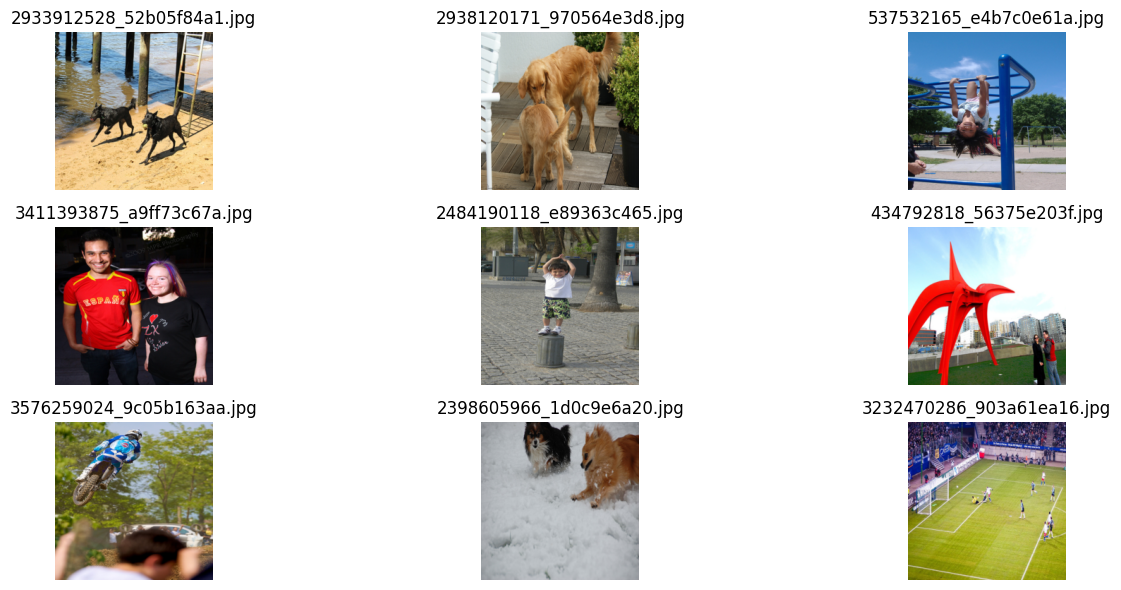

In [ ]:
# 1. Создание кастомного Dataset
class ImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.transform = transform
        # Поддерживаемые расширения изображений
        self.image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
        # Получаем список всех изображений
        self.image_paths = [f for f in self.image_dir.iterdir() if f.suffix.lower() in self.image_extensions]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, img_path.name


# 2. Определение трансформаций
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Изменение размера
    transforms.ToTensor(),  # Преобразование в тензор
    transforms.Normalize(  # Нормализация
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 3. Создание датасета и DataLoader
image_dir = f"{DATA_PATH}/train_images"
dataset = ImageDataset(image_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=9, shuffle=True)

# 4. Вывод 9 изображений на экран
def show_images(dataloader):
    # Получаем одну партию изображений
    images, filenames = next(iter(dataloader))

    # Денормализация для отображения
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images = images * std + mean

    # Отображение изображений
    fig, axes = plt.subplots(3, 3, figsize=(15, 6))
    axes = axes.flatten()

    for i, (img, ax) in enumerate(zip(images, axes)):
        # Преобразование тензора обратно в numpy
        img = img.permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(filenames[i])
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# Вызов функции
show_images(dataloader)


### Промежуточные выводы

Данные загружены, выглядят корректно.

Пропусков нет, дубликатов нет, типы данных в целом определены правильно. Для датасета experts_df типы данных столбцов exp1, exp2, exp3 определены некорректно. Несмотря на то, что в них содержатся числа, по сути это категориальные признаки. Но приводить их к типу category неудобно, т.к. необходимо будет считать общую экспертную и взвешенную оценку. Для этих целей лучше использовать числа.

## Исследовательский анализ данных

Наш датасет содержит экспертные и краудсорсинговые оценки соответствия текста и изображения.

В файле с экспертными мнениями для каждой пары изображение-текст имеются оценки от трёх специалистов. Для решения задачи вы должны эти оценки агрегировать — превратить в одну. Существует несколько способов агрегации оценок, самый простой — голосование большинства: за какую оценку проголосовала большая часть экспертов (в нашем случае 2 или 3), та оценка и ставится как итоговая. Поскольку число экспертов меньше числа классов, может случиться, что каждый эксперт поставит разные оценки, например: 1, 4, 2. В таком случае данную пару изображение-текст можно исключить из датасета.

Вы можете воспользоваться другим методом агрегации оценок или придумать свой.

В файле с краудсорсинговыми оценками информация расположена в таком порядке:

1. Доля исполнителей, подтвердивших, что текст **соответствует** картинке.
2. Количество исполнителей, подтвердивших, что текст **соответствует** картинке.
3. Количество исполнителей, подтвердивших, что текст **не соответствует** картинке.

После анализа экспертных и краудсорсинговых оценок выберите либо одну из них, либо объедините их в одну по какому-то критерию: например, оценка эксперта принимается с коэффициентом 0.6, а крауда — с коэффициентом 0.4.

Ваша модель должна возвращать на выходе вероятность соответствия изображения тексту, поэтому целевая переменная должна иметь значения от 0 до 1.


#### Experts

In [ ]:
# приведение к category
expert_df_category_columns = [
    "exp1",
    "exp2",
    "exp3",
]

# for col in expert_df_category_columns:
#     expert_df[col] = expert_df[col].astype("category")
#
# expert_df.info()

In [ ]:
expert_df_eda_results = eda_analysis(expert_df, dataset_name="Experts", verbose=True)

📊 ОБЩИЕ СВЕДЕНИЯ О ДАТАСЕТЕ: Experts
• Количество строк: 5,822
• Количество столбцов: 5
• Использование памяти: 0.96 MB

--------------------------------------------------------------------------------
📋 ТИПЫ ДАННЫХ СТОЛБЦОВ
--------------------------------------------------------------------------------
• Числовых столбцов: 3
• Категориальных столбцов: 2
• Столбцов с датой/временем: 0
• Булевых столбцов: 0

--------------------------------------------------------------------------------
📈 СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ КОЛИЧЕСТВЕННЫХ ПРИЗНАКОВ
--------------------------------------------------------------------------------
Столбец                        count         mean       median          std          min          max
---------------------------------------------------------------------------------------------------------
exp1                            5822         1.44         1.00         0.79         1.00         4.00
exp2                            5822         1.62         1

In [ ]:
visualize_categorical_columns(expert_df, expert_df_category_columns)

#### Crowd

In [ ]:
crowd_df_eda_results = eda_analysis(crowd_df, dataset_name="Crowd", verbose=True)

📊 ОБЩИЕ СВЕДЕНИЯ О ДАТАСЕТЕ: Crowd
• Количество строк: 47,830
• Количество столбцов: 5
• Использование памяти: 7.92 MB

--------------------------------------------------------------------------------
📋 ТИПЫ ДАННЫХ СТОЛБЦОВ
--------------------------------------------------------------------------------
• Числовых столбцов: 3
• Категориальных столбцов: 2
• Столбцов с датой/временем: 0
• Булевых столбцов: 0

--------------------------------------------------------------------------------
📈 СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ КОЛИЧЕСТВЕННЫХ ПРИЗНАКОВ
--------------------------------------------------------------------------------
Столбец                        count         mean       median          std          min          max
---------------------------------------------------------------------------------------------------------
match_pct                      47830         0.07         0.00         0.21         0.00         1.00
confirm                        47830         0.21         0.

In [ ]:
visualize_numerical_distribution_and_range(crowd_df)

#### Train data

In [ ]:
train_df_eda_results = eda_analysis(train_df, dataset_name="Train", verbose=True)

📊 ОБЩИЕ СВЕДЕНИЯ О ДАТАСЕТЕ: Train
• Количество строк: 5,822
• Количество столбцов: 3
• Использование памяти: 1.41 MB

--------------------------------------------------------------------------------
📋 ТИПЫ ДАННЫХ СТОЛБЦОВ
--------------------------------------------------------------------------------
• Числовых столбцов: 0
• Категориальных столбцов: 3
• Столбцов с датой/временем: 0
• Булевых столбцов: 0

--------------------------------------------------------------------------------
📈 СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ КОЛИЧЕСТВЕННЫХ ПРИЗНАКОВ
--------------------------------------------------------------------------------
• Числовые столбцы не найдены

--------------------------------------------------------------------------------
🏷️  ОПИСАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
--------------------------------------------------------------------------------
📌 image
   • Уникальных значений: 1000 (17.18% от данных)
   • Мода: 1339596997_8ac29c1841.jpg (частота: 10, 0.17%)
   • Топ-5 значений:
   

Проведем анализ поля query_text

In [ ]:
train_df['text_len'] = train_df['query_text'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
train_df['word_count'] = train_df['query_text'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

print(f'Средняя длина описания: {train_df["text_len"].mean():.1f} символов')
print(f'Среднее количество слов в описании: {train_df["word_count"].mean():.1f} слов')

Средняя длина описания: 55.2 символов
Среднее количество слов в описании: 11.9 слов


In [ ]:
text_columns = [
    'text_len',
    'word_count',
]

visualize_numerical_distribution_and_range(train_df, text_columns)

Построим wordcloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


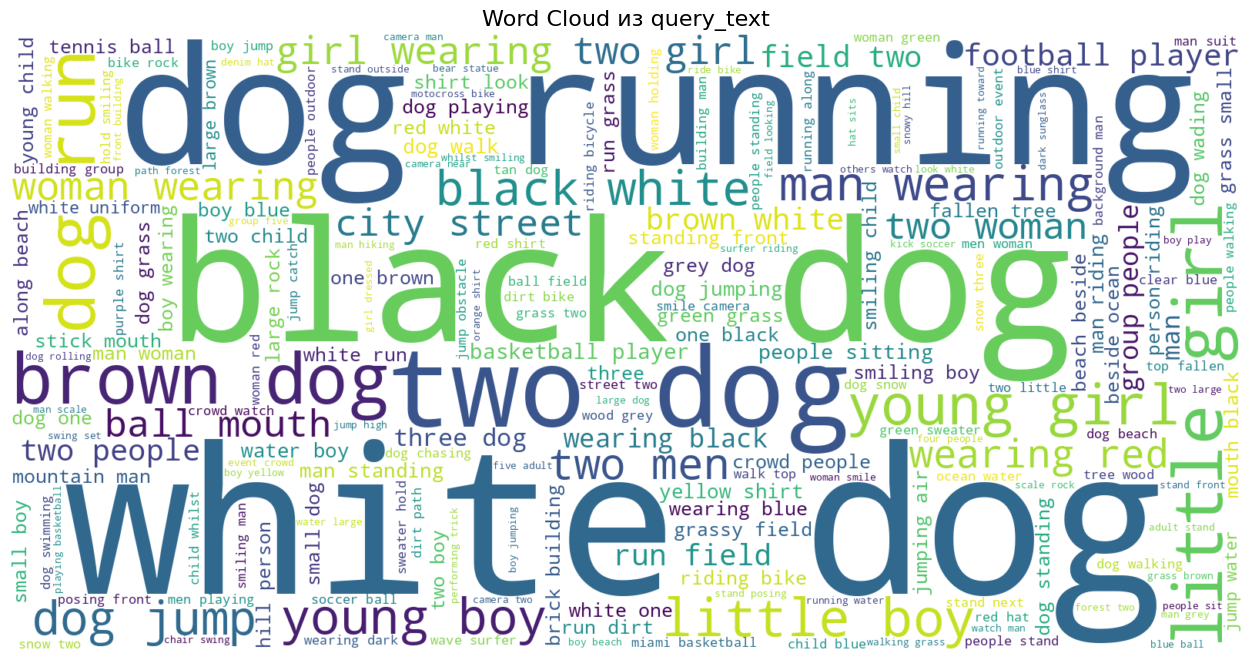


ТОП-10 наиболее частых слов:
 1. dog        : 1569
 2. man        : 999
 3. two        : 841
 4. white      : 697
 5. woman      : 631
 6. boy        : 591
 7. girl       : 584
 8. black      : 516
 9. wearing    : 450
10. water      : 444


In [ ]:
# Скачивание данных NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Инициализация инструментов
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


# Предобработка текста
def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    processed = [lemmatizer.lemmatize(t) for t in tokens
                 if t not in stop_words and len(t) > 2]
    return ' '.join(processed)


# Обработка всех текстов
train_df['query_text_processed'] = train_df['query_text'].apply(preprocess_text)
all_text = ' '.join(train_df['query_text_processed'].dropna())

# Создание облака слов
wordcloud = WordCloud(width=1600, height=800, background_color='white').generate(all_text)

# Отображение графика
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud из query_text', fontsize=16)
plt.show()

# Топ-10 наиболее частых слов
words = all_text.split()
top_words = Counter(words).most_common(10)

print("\nТОП-10 наиболее частых слов:")
for i, (word, count) in enumerate(top_words, 1):
    print(f"{i:2d}. {word:<10} : {count}")

#### Test queries

In [ ]:
test_queries_df_eda_results = eda_analysis(test_queries_df, dataset_name="Test Queries", verbose=True)

📊 ОБЩИЕ СВЕДЕНИЯ О ДАТАСЕТЕ: Test Queries
• Количество строк: 500
• Количество столбцов: 3
• Использование памяти: 0.13 MB

--------------------------------------------------------------------------------
📋 ТИПЫ ДАННЫХ СТОЛБЦОВ
--------------------------------------------------------------------------------
• Числовых столбцов: 0
• Категориальных столбцов: 3
• Столбцов с датой/временем: 0
• Булевых столбцов: 0

⚠️  СТОЛБЦЫ, ТРЕБУЮЩИЕ ПРЕОБРАЗОВАНИЯ:
   • query_id: рекомендуется → drop/index (уникальный идентификатор)
   • query_text: рекомендуется → drop/index (уникальный идентификатор)

--------------------------------------------------------------------------------
📈 СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ КОЛИЧЕСТВЕННЫХ ПРИЗНАКОВ
--------------------------------------------------------------------------------
• Числовые столбцы не найдены

--------------------------------------------------------------------------------
🏷️  ОПИСАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
------------------------------------

### Промежуточные выводы

- приведены типы в experts_df
- построены диграммы для отдельных количественных и категориальных признаков
- эксперты считают, что запрос чаще не соответствует изображению, либо запрос содержит элементы описания, но в целом не соответствует
- exp1 самый строгий, exp3 самый лояльный
- краудсорсинговые данные показывают, что люди чаще видят несоответствие изображения и описания
- средняя длина описания составляет 55.2 символов
- среднее количество слов в описании составляет 11.9 слов
- наиболее часто в описании изображений встречается слово dog (1569 раз)

## Подготовка данных

### Объединение данных

Объединим датасеты для тренировки.

Поскольку train_df содержит базовую информацию, а crowd_df и expert_df содержат дополнительную информацию, то выберем left join при объединении датасетов для сохранения всех данных из train_df.

In [ ]:
# Объединяем train_df с crowd_df и expert_df, сохраняя все записи из train_df
merged_df = (
    train_df
    .merge(crowd_df, on=['image', 'query_id'], how='left')
    .merge(expert_df, on=['image', 'query_id'], how='left')
)
merged_df.head()

,image,query_id,query_text,text_len,word_count,query_text_processed,match_pct,confirm,reject,exp1,exp2,exp3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,0.00,0.00,3.00,1,1,1
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,NaN,NaN,NaN,1,1,1
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,0.00,0.00,3.00,1,2,2
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,1.00,3.00,0.00,4,4,4
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,NaN,NaN,NaN,1,1,1


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image                 5822 non-null   object 
 1   query_id              5822 non-null   object 
 2   query_text            5822 non-null   object 
 3   text_len              5822 non-null   int64  
 4   word_count            5822 non-null   int64  
 5   query_text_processed  5822 non-null   object 
 6   match_pct             2329 non-null   float64
 7   confirm               2329 non-null   float64
 8   reject                2329 non-null   float64
 9   exp1                  5822 non-null   int64  
 10  exp2                  5822 non-null   int64  
 11  exp3                  5822 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 545.9+ KB


### Заполнение пропусков

Пропуски в колонках match_pct, confirm и reject означают, что краудсорс их не оценивал.

Заполнять их какими-либо значениями нельзя, т.к. это искажает смысл данных. Обработаем эти пропуски в формуле при подсчете взвешенной оценки

In [ ]:
merged_df.isna().sum()

,0
image,0
query_id,0
query_text,0
text_len,0
word_count,0
query_text_processed,0
match_pct,3493
confirm,3493
reject,3493
exp1,0


### Агрегация экспертных оценок

Голосование большинства

- Если 2 из 3 экспертов согласны → используем эту оценку
- Если все три разные (1, 2, 4) → исключаем из датасета

In [ ]:
def aggregate_votes(row):
    votes = [row['exp1'], row['exp2'], row['exp3']]
    vote_counts = Counter(votes)
    most_common = vote_counts.most_common(2)
    if most_common[0][1] >= 2:
        return most_common[0][0], True
    else:
        return np.nan, False


merged_df['aggregated'], merged_df['is_valid'] = zip(*merged_df.apply(aggregate_votes, axis=1))
merged_valid_expert_df = merged_df[merged_df['is_valid']]
merged_valid_expert_df.head()

,image,query_id,query_text,text_len,word_count,query_text_processed,match_pct,confirm,reject,exp1,exp2,exp3,aggregated,is_valid
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,0.00,0.00,3.00,1,1,1,1.00,True
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,NaN,NaN,NaN,1,1,1,1.00,True
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,0.00,0.00,3.00,1,2,2,2.00,True
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,1.00,3.00,0.00,4,4,4,4.00,True
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,NaN,NaN,NaN,1,1,1,1.00,True


Проверим размерность получившегося датасета

In [ ]:
check_size(merged_valid_expert_df, merged_df)

Количество записей в оригинальном датасете: 5822
Количество записей в текущем датасете: 5696
Количество удаленных записей: 126
Процент от начального объема данных: 97.84%


### Нормализация экспертных оценок

Нормализуем экспертные оценки из диапазона 1–4 в диапазон 0–1. Это необходимо для:

- Унификации шкал — экспертные оценки (1–4) и краудсорсинговые (0–1 в виде доли подтверждений) имеют разные диапазоны
- Комбинирования источников — для взвешенной суммы: final_score = 0.6 * expert_normalized + 0.4 * crowd_percentage
- Согласования с целевой переменной — итоговый таргет должен быть в диапазоне [0, 1]

Будем использовать MinMax нормализацию. Это позволяет:

- Интерпретировать оценку как "процент соответствия"
- Корректно смешивать с краудсорсинговыми данными
- Использовать единые пороги (например, > 0.5 = положительный пример)

Влияние

- Для модели: нормализованные значения не "перевешивают" один источник данных
- Для интерпретации: 0 = нет соответствия, 1 = полное соответствие

In [ ]:
merged_valid_expert_df['expert_normalized'] = (merged_valid_expert_df['aggregated'] - 1) / 3

### Получение target

Для получения target будем использовать взвешенную комбинацию (0.6 эксперты + 0.4 краудсорсинг) для баланса качества и количества.

In [ ]:
merged_valid_expert_df['target'] = np.where(
    merged_valid_expert_df['match_pct'].isna(),
    merged_valid_expert_df['expert_normalized'],
    0.6 * merged_valid_expert_df['expert_normalized'] + 0.4 * merged_valid_expert_df['match_pct']
)

merged_valid_expert_df.head()

,image,query_id,query_text,text_len,word_count,query_text_processed,match_pct,confirm,reject,exp1,exp2,exp3,aggregated,is_valid,expert_normalized,target
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,0.00,0.00,3.00,1,1,1,1.00,True,0.00,0.00
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,NaN,NaN,NaN,1,1,1,1.00,True,0.00,0.00
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,0.00,0.00,3.00,1,2,2,2.00,True,0.33,0.20
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,1.00,3.00,0.00,4,4,4,4.00,True,1.00,1.00
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,72,16,young child wearing blue goggles sitting float pool,NaN,NaN,NaN,1,1,1,1.00,True,0.00,0.00


In [ ]:
merged_valid_expert_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5696 entries, 0 to 5821
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image                 5696 non-null   object 
 1   query_id              5696 non-null   object 
 2   query_text            5696 non-null   object 
 3   text_len              5696 non-null   int64  
 4   word_count            5696 non-null   int64  
 5   query_text_processed  5696 non-null   object 
 6   match_pct             2258 non-null   float64
 7   confirm               2258 non-null   float64
 8   reject                2258 non-null   float64
 9   exp1                  5696 non-null   int64  
 10  exp2                  5696 non-null   int64  
 11  exp3                  5696 non-null   int64  
 12  aggregated            5696 non-null   float64
 13  is_valid              5696 non-null   bool   
 14  expert_normalized     5696 non-null   float64
 15  target                5696

Удалим все "лишние" столбцы

In [ ]:
merged_valid_expert_df = merged_valid_expert_df.drop(columns=[
    'match_pct',
    'confirm',
    'reject',
    'exp1',
    'exp2',
    'exp3',
    'aggregated',
    'expert_normalized',
])

### Промежуточные выводы

Проведено:

- объединение данных
- заполнение пропусков после объединения
- агрегация экспертных оценок
- нормализация экспертных оценок
- получение взвешенных target значений

## Проверка данных

В некоторых странах, где работает ваша компания, действуют ограничения по обработке изображений: поисковым сервисам и сервисам, предоставляющим возможность поиска, запрещено без разрешения родителей или законных представителей предоставлять любую информацию, в том числе, но не исключительно тексты, изображения, видео и аудио, содержащие описание, изображение или запись голоса детей. Ребёнком считается любой человек, не достигший 16 лет.

В вашем сервисе строго следуют законам стран, в которых работают. Поэтому при попытке посмотреть изображения, запрещённые законодательством, вместо картинок показывается дисклеймер:

> This image is unavailable in your country in compliance with local laws
>

Однако у вас в PoC нет возможности воспользоваться данным функционалом. Поэтому все изображения, которые нарушают данный закон, нужно удалить из обучающей выборки.

Методы обнаружения

Поиск ключевых слов в query_text: child, boy, girl, baby, kid, children, toddler, infant

In [ ]:
CHILD_KEYWORDS = [
    r'\w*child\w*',
    r'\w*boy\w*',
    r'\w*girl\w*',
    r'\w*baby\w*',
    r'\w*kid\w*',
    r'\w*children\w*',
    r'\w*toddler\w*',
    r'\w*infant\w*',
]


def contains_child(text):
    if pd.isna(text): return False
    for kw in CHILD_KEYWORDS:
        if re.search(kw, text.lower()): return True
    return False


merged_valid_expert_df['has_child'] = merged_valid_expert_df['query_text'].apply(contains_child)

print(f'Общее количество строк: {len(merged_valid_expert_df)}')
print(f'Количество записей, попадающих под ограничения: {merged_valid_expert_df["has_child"].sum()}')
print(f'Объем записей с ограничениями: {merged_valid_expert_df["has_child"].mean() * 100:.2f}%')

Общее количество строк: 5696
Количество записей, попадающих под ограничения: 1535
Объем записей с ограничениями: 26.95%


Удалим из датасета данные с детьми

In [ ]:
cleaned_df = merged_valid_expert_df[~merged_valid_expert_df['has_child']].copy()

Получение результирующего датасета для обучения модели

In [ ]:
result_df = cleaned_df[['image', 'query_id', 'query_text', 'target']].copy()
result_df.head()

,image,query_id,query_text,target
22,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.00
23,3187395715_f2940c2b72.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.33
24,463978865_c87c6ca84c.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.20
25,488590040_35a3e96c89.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.33
26,534875358_6ea30d3091.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.00


In [ ]:
check_size(result_df, train_df)

Количество записей в оригинальном датасете: 5822
Количество записей в текущем датасете: 4161
Количество удаленных записей: 1661
Процент от начального объема данных: 71.47%


Найдем также список "плохих" изображений и удалим их из датасета

In [ ]:
restricted_image_list = [x[:-2] for x in
                         merged_valid_expert_df[merged_valid_expert_df['has_child']]['query_id'].unique()]
restricted_image_list[:5]

['2549968784_39bfbe44f9.jpg',
 '2718495608_d8533e3ac5.jpg',
 '3545652636_0746537307.jpg',
 '1714316707_8bbaa2a2ba.jpg',
 '2140182410_8e2a06fbda.jpg']

In [ ]:
result_df = result_df.query("image not in @restricted_image_list")

In [ ]:
check_size(result_df, train_df)

Количество записей в оригинальном датасете: 5822
Количество записей в текущем датасете: 3091
Количество удаленных записей: 2731
Процент от начального объема данных: 53.09%


### Промежуточные выводы

- проведена очистка данных для соответствия юридическим ограничениям
- сформирован результирующий датасет для обучения модели

## Векторизация изображений

Перейдём к векторизации изображений.

Самый примитивный способ — прочесть изображение и превратить полученную матрицу в вектор. Такой способ нам не подходит: длина векторов может быть сильно разной, так как размеры изображений разные. Поэтому стоит обратиться к свёрточным сетям: они позволяют "выделить" главные компоненты изображений. Как это сделать? Нужно выбрать какую-либо архитектуру, например ResNet-18, посмотреть на слои и исключить полносвязные слои, которые отвечают за конечное предсказание. При этом можно загрузить модель данной архитектуры, предварительно натренированную на датасете ImageNet.

Создадим необходимые функции для векторизации изображений с использованием модели ResNet-18

In [ ]:
def load_feature_extractor():
    """
    Загрузка предобученной модели ResNet-18 и создание модели извлечения признаков.
    Удаляются финальные полносвязные слои для получения признаков из pooling-слоя.

    Returns:
        torch.nn.Sequential: Модель для извлечения признаков
    """
    # Загрузка предобученной модели ResNet-18
    model = models.resnet18(weights='DEFAULT')

    # Удаление последнего полносвязного слоя (fc)
    # Берем все слои КРОМЕ последнего (fc)
    feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])

    # Установка режима оценки
    feature_extractor.eval()

    return feature_extractor


In [ ]:
def get_image_transform():
    """
    Создание трансформаций для предобработки изображения.
    Стандартные параметры нормализации ImageNet.

    Returns:
        torchvision.transforms.Compose: Цепочка преобразований
    """
    transform = transforms.Compose([
        transforms.Resize(256),  # Изменение размера (мин. сторона = 256)
        transforms.CenterCrop(224),  # Центральная обрезка до 224x224
        transforms.ToTensor(),  # Преобразование в тензор [0, 1]
        transforms.Normalize(  # Нормализация ImageNet
            mean=[0.485, 0.456, 0.406],  # Среднее значение по каналам
            std=[0.229, 0.224, 0.225]  # Стандартное отклонение по каналам
        )
    ])
    return transform


In [ ]:
def extract_features(image_path, feature_extractor, transform):
    """
    Извлечение вектора признаков из изображения.

    Args:
        image_path (str): Путь к изображению
        feature_extractor (torch.nn.Sequential): Модель извлечения признаков
        transform (torchvision.transforms.Compose): Трансформации изображения

    Returns:
        numpy.ndarray: Вектор признаков изображения
    """
    # Загрузка и преобразование изображения
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0)  # Добавляем batch dimension

    # Извлечение признаков без вычисления градиентов
    with torch.no_grad():
        features = feature_extractor(image_tensor)
        # Удаление размерностей: [1, 512, 1, 1] -> [512]
        features = features.squeeze()

    return features.numpy()


In [ ]:
def vectorize_image(image_path: str, feature_extractor, transform, test_images: bool = False):
    images_folder = "test_images" if test_images else "train_images"
    test_image_path = os.path.join(DATA_PATH, images_folder, image_path)
    if os.path.exists(test_image_path):
        return extract_features(test_image_path, feature_extractor, transform)
    else:
        print(f"Изображение не найдено: {test_image_path}")
        return None

In [ ]:
# Загрузка предобученной модели
feature_extractor = load_feature_extractor()

# Получение трансформаций
transform = get_image_transform()

# Векторизация изображений
result_df["image_vectorized"] = result_df["image"].apply(vectorize_image, args=(feature_extractor, transform))
result_df.head()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 99.3MB/s]


,image,query_id,query_text,target,image_vectorized
22,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.00,"[0.69394046, 3.0318356, 2.9169335, 0.9518981, 0.93629503, 1.2451165, 0.8265243, 1.1079426, 0.16967924, 0.36538252, 0.25528422, 1.4858478, 0.30727926, 1.2506149, 0.042873353, 0.8068845, 0.930602, 0.6955927, 0.25997928, 1.6920058, 0.3307255, 0.82490027, 2.2854967, 1.9401357, 1.1208282, 0.7317041, 1.3495178, 0.45218, 0.3212068, 0.5514583, 2.1656032, 0.22816662, 0.79771024, 1.5144424, 1.0655708, 0.9009829, 0.56120527, 1.0666708, 0.23442988, 1.1879426, 0.8099352, 1.1380215, 1.2138017, 1.0139208, 0.45755294, 0.8241552, 0.6527926, 0.0044504115, 0.76137686, 3.0095713, 0.37051645, 0.12700038, 0.6486456, 0.13020575, 0.48984337, 0.2870085, 0.349888, 1.4781904, 1.4833767, 0.8156039, 1.8636606, 1.4660727, 1.3917418, 0.94194466, 0.7517898, 0.23120679, 0.14655122, 0.50500196, 0.19545479, 1.2660745, 1.3832078, 0.65568393, 0.21737386, 0.135384, 0.7692921, 0.16667187, 0.72972006, 0.43480933, 1.1738667, 0.3593344, 0.47992545, 1.0286529, 0.27197626, 0.70399296, 0.8009375, 1.4706188, 0.622824, 0.5263413, 2.292714, 1.0442916, 0.5663149, 0.8545169, 1.0603186, 1.7736515, 0.22238128, 1.0299959, 0.64702505, 0.628322, 0.2611921, 0.54734725, ...]"
23,3187395715_f2940c2b72.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.33,"[0.2719132, 2.4822745, 1.6199743, 1.2389054, 1.7955568, 0.70018846, 0.33372176, 0.6826286, 0.4589157, 0.7050056, 1.0758916, 0.367551, 0.7681486, 0.4795311, 2.065324, 1.0712742, 0.051574003, 0.05317802, 1.9836879, 0.9321586, 0.58893156, 1.5395969, 1.1321874, 0.93722564, 0.1692454, 1.1579077, 0.7216884, 2.1139925, 0.039602865, 0.29921198, 0.30572373, 0.101471245, 0.17224218, 0.0, 0.26701626, 0.46167693, 0.847037, 0.07694539, 0.0481798, 1.6543816, 0.50791585, 0.7291196, 1.9003745, 1.9941082, 0.77397865, 0.7526663, 0.7615524, 0.1364461, 0.41839144, 2.0842197, 0.48487765, 0.9479938, 0.28386995, 1.1891483, 0.48389727, 3.265391, 1.1765743, 0.028372725, 1.087484, 0.29163367, 0.99521536, 1.6042517, 1.9378538, 0.639246, 1.6170089, 1.2303114, 3.166312, 0.014875507, 1.7914902, 1.6222408, 0.060847316, 0.36007273, 0.14392656, 0.23117274, 0.8897031, 0.41476882, 0.24223599, 0.24049443, 0.6865638, 0.19984436, 0.7385086, 0.056875043, 0.8885715, 1.0744386, 2.276021, 0.93024623, 1.494864, 0.2808333, 2.3628924, 1.4702044, 0.6152257, 0.87618, 0.8280579, 0.2871595, 0.3958973, 0.6021418, 0.17174767, 2.7656982, 0.6370202, 0.034657132, ...]"
24,463978865_c87c6ca84c.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.20,"[0.9807002, 3.829267, 1.2966526, 0.8038089, 0.5167023, 0.4091234, 0.7240303, 0.83880407, 0.24427469, 0.39681345, 0.49595556, 0.53891325, 0.63850254, 0.10871403, 0.6902675, 1.1092229, 1.883939, 0.026691824, 0.3096169, 0.6339732, 0.23690543, 0.83908844, 1.6135652, 1.2375852, 1.0366342, 0.16812164, 0.5494993, 0.4918278, 0.66910213, 0.8627581, 0.64526945, 0.050546665, 0.51378506, 0.046345033, 0.6285701, 0.4480743, 0.24614307, 0.507196, 0.17441921, 0.2177751, 0.2200751, 0.25555053, 0.4975034, 1.5890944, 1.093152, 0.44172323, 0.37878668, 0.00010403425, 0.45806444, 0.3502922, 0.13421914, 0.4676369, 0.47739148, 1.1125484, 0.88399637, 0.39613912, 1.5345984, 0.29834723, 2.076523, 0.29258302, 0.09518858, 0.48874465, 0.8477935, 0.2766232, 0.23612358, 0.9963501, 1.4870464, 0.011880906, 1.5711029, 0.53170335, 0.6763186, 0.59437436, 1.0104198, 0.07262116, 0.90345925, 0.71117043, 0.2537832, 0.7839444, 0.23088607, 1.2866648, 0.3953939, 0.65949583, 0.32766813, 1.7579707, 0.65858024, 0.50799084, 0.364331, 0.52459985, 3.350721, 0.28296748, 0.6486206, 0.8022652, 1.3601929, 1.6065013, 0.42900187, 0.79458916, 0.68481845, 1.8199855, 0.26758528, 0.14632298, ...]"
25,488590040_35a3e96c89.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.33,"[1.5195093, 1.0709542, 0.17877108, 0.29753155, 0.5677908, 0.14353582, 1.374602

## Векторизация текстов

Следующий этап — векторизация текстов. Вы можете поэкспериментировать с несколькими способами векторизации текстов:

- tf-idf
- word2vec
- \*трансформеры (например Bert)

\* — если вы изучали трансформеры в спринте Машинное обучение для текстов.


In [ ]:
def get_bert_embeddings(
        texts: Union[str, List[str]],
        model_name: str = "bert-base-cased",
        tokenizer: Any = None,
        model: Any = None,
        device: str = None
) -> np.ndarray:
    """
    Получение эмбеддингов BERT для текста.

    Параметры:
    -----------
    texts : str или List[str]
        Текст или список текстов
    model_name : str
        Имя предобученной модели
    tokenizer : Any
        Токенизатор
    model : Any
        Модель
    device : str
        Устройство ('cuda' или 'cpu')

    Возвращает:
    ------------
    np.ndarray
        Массив эмбеддингов
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    if tokenizer is None:
        tokenizer = BertTokenizer.from_pretrained(model_name)

    if model is None:
        model = BertModel.from_pretrained(
            model_name,
            output_hidden_states=True,
            token=False,
            output_loading_info=False
        )

    model.to(device)
    model.eval()

    single_text = isinstance(texts, str)
    if single_text:
        texts = [texts]

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    hidden_states = outputs.hidden_states

    # Mean pooling
    mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states[-1].size()).float()
    sum_embeddings = torch.sum(hidden_states[-1] * mask_expanded, 1)
    sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
    embeddings = sum_embeddings / sum_mask

    result = embeddings.cpu().numpy()

    if single_text:
        return result[0]
    return result


In [ ]:
MODEL_NAME = "bert-base-cased"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
    token=False,
    output_loading_info=False
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

device: cpu


In [ ]:
# ТЕСТ: Одиночный текст
text = "This is an example sentence for embedding extraction."
embedding = get_bert_embeddings(text, tokenizer=tokenizer, model=model, device=device)
print(f"Single text embedding shape: {embedding.shape}")
print(f"First 5 values: {embedding[:5]}")

# ТЕСТ: Несколько текстов
texts = [
    "Machine learning is fascinating.",
    "Natural language processing is fun.",
    "Deep learning uses neural networks."
]
embeddings = get_bert_embeddings(texts, tokenizer=tokenizer, model=model, device=device)
print(f"\nMultiple texts embedding shape: {embeddings.shape}")

Single text embedding shape: (768,)
First 5 values: [ 0.44072014  0.19628827  0.03091597 -0.05881515 -0.13281013]

Multiple texts embedding shape: (3, 768)


In [ ]:
result_df["query_text_vectorized"] = get_bert_embeddings(
    result_df["query_text"].tolist(),
    tokenizer=tokenizer,
    model=model,
    device=device
).tolist()
result_df.head()

,image,query_id,query_text,target,image_vectorized,query_text_vectorized
22,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.00,"[0.69394046, 3.0318356, 2.9169335, 0.9518981, 0.93629503, 1.2451165, 0.8265243, 1.1079426, 0.16967924, 0.36538252, 0.25528422, 1.4858478, 0.30727926, 1.2506149, 0.042873353, 0.8068845, 0.930602, 0.6955927, 0.25997928, 1.6920058, 0.3307255, 0.82490027, 2.2854967, 1.9401357, 1.1208282, 0.7317041, 1.3495178, 0.45218, 0.3212068, 0.5514583, 2.1656032, 0.22816662, 0.79771024, 1.5144424, 1.0655708, 0.9009829, 0.56120527, 1.0666708, 0.23442988, 1.1879426, 0.8099352, 1.1380215, 1.2138017, 1.0139208, 0.45755294, 0.8241552, 0.6527926, 0.0044504115, 0.76137686, 3.0095713, 0.37051645, 0.12700038, 0.6486456, 0.13020575, 0.48984337, 0.2870085, 0.349888, 1.4781904, 1.4833767, 0.8156039, 1.8636606, 1.4660727, 1.3917418, 0.94194466, 0.7517898, 0.23120679, 0.14655122, 0.50500196, 0.19545479, 1.2660745, 1.3832078, 0.65568393, 0.21737386, 0.135384, 0.7692921, 0.16667187, 0.72972006, 0.43480933, 1.1738667, 0.3593344, 0.47992545, 1.0286529, 0.27197626, 0.70399296, 0.8009375, 1.4706188, 0.622824, 0.5263413, 2.292714, 1.0442916, 0.5663149, 0.8545169, 1.0603186, 1.7736515, 0.22238128, 1.0299959, 0.64702505, 0.628322, 0.2611921, 0.54734725, ...]","[0.16216424107551575, -0.1497913897037506, 0.04065414145588875, 0.2613733112812042, 0.20599548518657684, 0.03483174741268158, 0.07731277495622635, -0.004618507344275713, 0.08992239087820053, -0.20171478390693665, -0.2361185997724533, 0.5096349120140076, -0.288360595703125, 0.06413505226373672, -0.3300284743309021, -0.20459046959877014, 0.14793919026851654, -0.044715918600559235, -0.05128272622823715, -0.30107322335243225, 0.0070258015766739845, -0.14110946655273438, -0.23881863057613373, 0.239031583070755, 0.08525047451257706, 0.030074188485741615, 0.052283499389886856, 0.9341464638710022, 0.12847529351711273, 0.25549742579460144, 0.037127695977687836, 0.05160961300134659, 0.23445989191532135, 0.1323404610157013, -0.15113483369350433, 0.09603822231292725, -0.18891872465610504, 0.2786196172237396, 0.042675551027059555, 0.01787150837481022, 0.04816272109746933, -0.19207416474819183, -0.005284764803946018, 0.24334529042243958, 0.034272536635398865, -0.2614997327327728, -0.020595457404851913, 0.07170727103948593, -0.032560549676418304, 0.12030712515115738, 0.26803240180015564, 0.14129163324832916, -0.10997967422008514, -0.008266142569482327, 0.09743894636631012, -0.262751966714859, -0.1319739818572998, 0.03775599226355553, -0.2964630126953125, 0.33906468749046326, 0.2800813615322113, 0.43664053082466125, 0.5899805426597595, 0.18582727015018463, 0.28412050008773804, 0.29872414469718933, 0.3042129576206207, -0.3468601703643799, 0.014130259864032269, -0.07500327378511429, 0.06940064579248428, 0.11038913577795029, -0.13328547775745392, 0.011714675463736057, 0.09784772247076035, -0.2497962862253189, 0.011810381896793842, 0.15944518148899078, -0.39058536291122437, -0.23664413392543793, 0.17989309132099152, 0.16320157051086426, -0.05635730177164078, 0.45714303851127625, 0.37079063057899475, 0.5441710948944092, 0.06870297342538834, -0.06844652444124222, 0.3495972454547882, 0.10167744010686874, 0.24779252707958221, -0.08100618422031403, 0.2963866889476776, -0.19878534972667694, 0.13409772515296936, 0.0913049727678299, -0.25190359354019165, 0.07289627939462662, 0.4353630244731903, -0.0773896723985672, ...]"
23,3187395715_f2940c2b72.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.33,"[0.2719132, 2.4822745, 1.6199743, 1.2389054, 1.7955568, 0.70018846, 0.33372176, 0.6826286, 0.4589157, 0.7050056, 1.0758916, 0.367551, 0.7681486, 0.4795311, 2.065324, 1.0712742, 0.051574003, 0.05317802, 1.9836879, 0.9321586, 0.58893156, 1.5395969, 1.1321874, 0.93722564, 0.1692454, 1.1579077, 0.7216884, 2.1139925, 0.039602865, 0.29921198, 0.30572373, 0.101471245, 0.17224218, 0.0, 0.26701626, 0.46167693, 0.847037, 0.07694539, 0.048179

## Объединение векторов

Подготовьте данные для обучения: объедините векторы изображений и векторы текстов с целевой переменной.

Нормализуем полученные векторы

In [ ]:
# result_df['image_vectorized_normalized'] = Normalizer(norm='l2').fit_transform(np.array(result_df['image_vectorized'].tolist())).tolist()
# result_df['query_text_vectorized_normalized'] = Normalizer(norm='l2').fit_transform(np.array(result_df['query_text_vectorized'].tolist())).tolist()
#
# result_df.head()

In [ ]:
# Преобразуем списки в numpy массивы
image_vectors = np.array(result_df['image_vectorized'].tolist())
text_vectors = np.array(result_df['query_text_vectorized'].tolist())
# image_vectors = np.array(result_df['image_vectorized_normalized'].tolist())
# text_vectors = np.array(result_df['query_text_vectorized_normalized'].tolist())
targets = result_df['target'].to_numpy()

print(f"Image vectors shape: {image_vectors.shape}")
print(f"Text vectors shape: {text_vectors.shape}")
print(f"Target shape: {targets.shape}")

Image vectors shape: (3091, 512)
Text vectors shape: (3091, 768)
Target shape: (3091,)


In [ ]:
# Объединяем признаки изображений и текстов по горизонтали
X = np.hstack([image_vectors, text_vectors])
y = targets

print(f"\nCombined features shape: {X.shape}")
print(f"  - Image: {image_vectors.shape[1]} признаков")
print(f"  - Text: {text_vectors.shape[1]} признаков")
print(f"  - Total: {X.shape[1]} признаков")


Combined features shape: (3091, 1280)
  - Image: 512 признаков
  - Text: 768 признаков
  - Total: 1280 признаков


In [ ]:
# Проверка соответствия размерностей
assert X.shape[0] == y.shape[0], "Ошибка: несовпадение количества записей!"
print(f"\n✓ Количество записей совпадает: {X.shape[0]}")

# Проверка на пропуски
has_nan = np.isnan(X).any()
print(f"✓ Нет NaN значений: {not has_nan}")

# Проверка типов и диапазонов
print(f"✓ Features dtype: {X.dtype}, range: [{X.min():.2f}, {X.max():.2f}]")
print(f"✓ Target dtype: {y.dtype}, range: [{y.min():.2f}, {y.max():.2f}]")


✓ Количество записей совпадает: 3091
✓ Нет NaN значений: True
✓ Features dtype: float64, range: [-8.41, 12.09]
✓ Target dtype: float64, range: [0.00, 1.00]


## Обучение модели предсказания соответствия

Для обучения разделите датасет на тренировочную и тестовую выборки. Простое случайное разбиение не подходит: нужно исключить попадание изображения и в обучающую, и в тестовую выборки.
Для того чтобы учесть изображения при разбиении, можно воспользоваться классом [GroupShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html) из библиотеки sklearn.model_selection.

Код ниже разбивает датасет на тренировочную и тестовую выборки в пропорции 7:3 так, что строки с одинаковым значением 'group_column' будут содержаться либо в тестовом, либо в тренировочном датасете.

```
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, train_size=.7, random_state=42)
train_indices, test_indices = next(gss.split(X=df.drop(columns=['target']), y=df['target'], groups=df['group_column']))
train_df, test_df = df.loc[train_indices], df.loc[test_indices]

```

Какую модель использовать — выберите самостоятельно. Также вам предстоит выбрать метрику качества либо реализовать свою.

Обучим несколько моделей для решения задачи регрессии и выберем лучшую из них

- Ridge
- Random Forest
- Neural Network

В качестве метрики оценки качества моделей будем использовать RMSE, т.к. единицы измерения целевой переменной и стандарт индустрии

In [ ]:
# Разбиение 70/30, группируем по изображениям
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=RANDOM_STATE)
train_indices, valid_indices = next(
    gss.split(X=X, y=y, groups=result_df['image'])
)

X_train, X_valid = X[train_indices], X[valid_indices]
y_train, y_valid = y[train_indices], y[valid_indices]

print(f"Train size: {X_train.shape[0]}, Test size: {X_valid.shape[0]}")

Train size: 2184, Test size: 907


In [ ]:
# Функция метрик
def evaluate_model(name, y_true, y_pred):
    """Вычисляет и выводит метрики качества"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}:")
    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

In [ ]:
# --- Модель 1: Ridge Regression ---

model_ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_valid)
metrics_ridge = evaluate_model("Ridge Regression", y_valid, y_pred_ridge)

Ridge Regression:
RMSE: 0.5091, MAE: 0.3972, R²: -1.8448


In [ ]:
# --- Модель 2: Random Forest ---

model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_valid)
metrics_rf = evaluate_model("Random Forest", y_valid, y_pred_rf)

Random Forest:
RMSE: 0.2826, MAE: 0.2183, R²: 0.1239


In [ ]:
# --- Модель 3: Neural Network (Pytorch) ---

# Переводим в float32 для экономии памяти
X_train_t = torch.FloatTensor(X_train.astype(np.float32))
y_train_t = torch.FloatTensor(y_train.astype(np.float32))
X_test_t = torch.FloatTensor(X_valid.astype(np.float32))
y_test_t = torch.FloatTensor(y_valid.astype(np.float32))

# DataLoader для батчевой загрузки
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Определение архитектуры
class SimilarityMLP(nn.Module):
    """
    Нейросеть для предсказания соответствия изображения и текста.
    Вход: 1280 признаков (512 image + 768 text)
    Выход: 1 число от 0 до 1
    """
    def __init__(self, input_dim=1280):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            # nn.LayerNorm(512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 128),
            # nn.LayerNorm(128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()  # Выход в диапазоне [0, 1]
        )

    def forward(self, x):
        return self.network(x).squeeze()

# Инициализация модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_nn = SimilarityMLP(input_dim=X_train.shape[1]).to(device)
# criterion = nn.BCEWithLogitsLoss()
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model_nn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# Обучение
epochs = 100
best_loss = float('inf')
# patience_counter = 0
# early_stop_patience = 10

print("\nОбучение нейросети...")
for epoch in range(epochs):
    model_nn.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model_nn(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Валидация
    model_nn.eval()
    with torch.no_grad():
        val_pred = model_nn(X_test_t.to(device))
        val_loss = criterion(val_pred, y_test_t.to(device)).item()

    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        # patience_counter = 0
        torch.save(model_nn.state_dict(), 'best_model_nn.pth')
    # else:
    #     patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # if patience_counter >= early_stop_patience:
    #     print(f"Early stopping на epoch {epoch+1}")
    #     break

# Загрузка лучшей модели
model_nn.load_state_dict(torch.load('best_model_nn.pth'))
model_nn.eval()

# Предсказания
with torch.no_grad():
    y_pred_nn = model_nn(X_test_t.to(device)).cpu().numpy()

metrics_nn = evaluate_model("Neural Network", y_valid, y_pred_nn)


Обучение нейросети...
Epoch 10/100, Train Loss: 0.0256, Val Loss: 0.0755
Epoch 20/100, Train Loss: 0.0125, Val Loss: 0.0797
Epoch 30/100, Train Loss: 0.0091, Val Loss: 0.0807
Epoch 40/100, Train Loss: 0.0076, Val Loss: 0.0804
Epoch 50/100, Train Loss: 0.0074, Val Loss: 0.0788
Epoch 60/100, Train Loss: 0.0076, Val Loss: 0.0810
Epoch 70/100, Train Loss: 0.0074, Val Loss: 0.0800
Epoch 80/100, Train Loss: 0.0085, Val Loss: 0.0800
Epoch 90/100, Train Loss: 0.0070, Val Loss: 0.0810
Epoch 100/100, Train Loss: 0.0074, Val Loss: 0.0818
Neural Network:
RMSE: 0.2725, MAE: 0.1941, R²: 0.1851


Сравнение моделей

In [ ]:
results = {
    'Ridge': metrics_ridge,
    'RandomForest': metrics_rf,
    'NeuralNetwork': metrics_nn
}

best_model_name = min(results, key=lambda x: results[x]['rmse'])
print(f"Лучшая модель: {best_model_name}, RMSE: {results[best_model_name]['rmse']:.4f}")

Лучшая модель: NeuralNetwork, RMSE: 0.2725


### Промежуточные выводы

Лучшей признана модель Neural Network. Метрика RMSE составила 0.23, что выглядит не очень, т.к. модель в среднем почти на 25% ошибается в определении средневзвешенной оценки.

## Тестирование модели

Настало время протестировать модель. Для этого получите эмбеддинги для всех тестовых изображений из папки `test_images`, выберите случайные 10 запросов из файла `test_queries.csv` и для каждого запроса выведите наиболее релевантное изображение. Сравните визуально качество поиска.

Для решения поставленной задачи создадим датасет, который будет включать в себя имена файлов изображений в директории train_images

In [ ]:
directory = os.path.join(DATA_PATH, "test_images")
print(directory)

file_data = [
    {
        'image': filename,
    }
    for filename in os.listdir(directory)
]

test_data_df = pd.DataFrame(file_data)
test_data_df.head()

./temp_data/datasets/test_images


,image
0,3262849619_0bc4f88ef9.jpg
1,2060031241_a3ae7a06bb.jpg
2,3386953179_84c2d7922f.jpg
3,3154152744_4e93ec8a62.jpg
4,1319634306_816f21677f.jpg


Добавим векторизацию изображений и их нормализацию

In [ ]:
test_data_df["image_vectorized"] = test_data_df["image"].apply(vectorize_image, args=(feature_extractor, transform, True))
# test_data_df["image_vectorized"] = Normalizer(norm='l2').fit_transform(np.array(test_data_df['image_vectorized'].tolist())).tolist()
test_data_df.head()

,image,image_vectorized
0,3262849619_0bc4f88ef9.jpg,"[1.9322834, 0.043440435, 0.49729896, 0.4363096, 0.94674283, 0.48875356, 0.03967359, 3.2296174, 0.84600246, 3.595404, 0.022954613, 1.2711353, 0.032246735, 0.21340498, 2.3779452, 0.2810519, 0.11749083, 1.2114232, 0.6009485, 0.20850845, 1.5670887, 2.6423879, 0.8596761, 0.42061388, 1.0301611, 0.3380313, 0.82631356, 1.780857, 1.1009084, 0.0011465442, 0.6716674, 0.40935206, 0.27237603, 0.122539625, 1.7983108, 2.590839, 0.62592417, 0.3814376, 1.281715, 0.8039962, 0.090823136, 1.32913, 0.6818366, 1.548572, 0.75251305, 0.9401664, 0.6664146, 0.016637092, 0.1643617, 0.72197926, 0.0128066465, 1.5903245, 0.46378934, 0.0009211907, 0.16992022, 0.034318145, 2.393112, 0.2903886, 0.03558317, 2.0843697, 0.5790763, 0.009687543, 0.82259977, 0.18252505, 0.8109967, 1.5693073, 0.025741426, 1.0054933, 0.6044488, 1.8992202, 0.79920065, 0.4224407, 0.68438315, 0.34880322, 0.44800442, 1.6571443, 0.66597724, 0.0046384386, 3.5457265, 0.38660634, 0.025462246, 0.58120775, 0.5094081, 3.2229168, 0.5202851, 1.4705627, 1.9221227, 1.4751482, 1.1437519, 1.0299829, 0.53929305, 1.104579, 0.4274564, 0.07532082, 0.024831567, 1.966085, 0.014041173, 0.44955203, 0.027053691, 0.052300688, ...]"
1,2060031241_a3ae7a06bb.jpg,"[1.480224, 0.23023772, 0.32484967, 0.2241478, 0.7897835, 1.6686647, 0.3507036, 2.4626093, 1.0436269, 0.2117439, 0.3827834, 0.93965816, 0.3540845, 0.72792095, 1.2405427, 0.31148684, 0.56321555, 0.25127178, 0.16803958, 0.79412663, 0.4966553, 0.018556464, 0.9994041, 1.4020946, 0.99725014, 0.46343705, 0.63596046, 1.2150153, 1.2341756, 0.7523425, 0.6803467, 0.8373622, 0.51274943, 0.49348488, 1.8980337, 0.19045188, 3.9749875, 0.61063504, 0.9388087, 1.0442653, 1.0872139, 0.7744083, 1.4387674, 0.7341509, 0.60145396, 1.2539008, 0.25100443, 5.575924, 1.9907315, 1.7781979, 0.7714299, 0.7684222, 1.0657933, 0.8539333, 0.7693922, 0.40384573, 0.21295807, 1.8938167, 0.5249967, 0.87064356, 0.15593253, 0.013250693, 0.834386, 0.6029097, 1.1891531, 0.5190952, 2.0178456, 0.5440758, 0.23523939, 0.32837167, 2.149606, 0.91086954, 0.47641474, 0.18261462, 0.5253878, 0.6437156, 0.77163726, 1.4209809, 0.8386863, 0.43974897, 1.9741759, 4.5049815, 0.9291075, 2.018209, 0.841496, 0.43503937, 0.9957725, 0.51684535, 2.0417218, 1.5708358, 1.7567234, 1.7380891, 0.7692452, 1.9407759, 1.1834235, 2.8707151, 1.6491902, 0.36271045, 0.46034122, 1.6778415, ...]"
2,3386953179_84c2d7922f.jpg,"[0.33542532, 0.8235916, 0.14608264, 2.0181699, 0.051180024, 0.36737815, 0.45432356, 2.470269, 0.7552716, 0.94372666, 0.0, 0.009762812, 0.6524295, 1.0949419, 0.383005, 0.0, 0.2635958, 4.836325, 0.20870668, 0.16897042, 0.30212775, 2.7683413, 1.0712212, 0.23541439, 0.9596479, 1.4239801, 0.9743077, 5.1018705, 0.82110465, 2.1267457, 1.0288664, 0.3637916, 1.5520004, 0.12753648, 1.5095458, 0.08756588, 0.0, 0.21805984, 0.43095204, 0.04168337, 0.31735927, 0.37055725, 0.004372207, 0.13579741, 1.4799117, 0.05234241, 0.064822, 0.1750376, 2.0158281, 0.4897822, 0.048871648, 0.28024682, 1.5645223, 0.0047882833, 1.316453, 2.1087358, 3.2540517, 3.2546353, 0.06597212, 0.116512746, 0.13149656, 2.3692493, 2.08019, 0.99046683, 0.43049634, 2.0818954, 0.77716136, 0.17247866, 0.013899909, 1.3657544, 0.9336508, 0.21860556, 0.43691665, 0.03673076, 0.5475992, 0.0, 0.044476822, 1.803459, 0.8665082, 0.627014, 0.35036647, 0.099051565, 1.7340535, 2.5154052, 0.07196912, 0.5721326, 0.7377598, 0.0, 0.24580735, 0.115389034, 0.0068732104, 0.25569654, 1.8291636, 1.8619899, 0.68227404, 0.059761383, 1.0953662, 0.0, 0.42979506, 0.3886913, ...]"
3,3154152744_4e93ec8a62.jpg,"[0.56232065, 0.20039134, 0.9464234, 0.052620377, 1.5092367, 0.32515472, 0.1956497, 1.9008224, 0.5539172, 4.559685, 0.31318313, 0.70361066, 0.03958321, 1.9543344, 1.4564489, 2.7280192, 0.37202927, 0.12883441, 0.689004, 0.32179704, 0.8646334, 3.9056048, 1.6488199, 1.3159648, 0.035266712, 1.4907286, 0.7186042, 1.939335, 0.031793028, 0.6221214, 0.5426064, 0.24548346, 0.45952708, 0.70428693, 0.9064026, 0.82112247, 1.9725811, 0.272486

Проверим, что все запросы в test_queries_df уникальные

In [ ]:
print(f"Всего записей: {len(test_queries_df)}, уникальных запросов: {len(test_queries_df['query_text'].unique())}")


Всего записей: 500, уникальных запросов: 500


Выберем 10 произвольных запросов

In [ ]:
n_queries = 10
test_query_text_list = list(test_queries_df["query_text"].sample(n_queries, random_state=RANDOM_STATE))
test_query_text_list

['A group of girls who are gothically dressed standing together',
 'A woman and girl riding downhill on a sled with a dog running alongside them',
 'The dog is running .',
 'A group of people are ice skating in a big city .',
 'Little kid in blue coat and hat riding a tricycle .',
 'Two black dogs fighting over an orange toy .',
 'A dog jumping for a tennis ball near an ocean',
 'Boy flying a distant kite .',
 'kids play ultimate Frisbee .',
 'A girl in a purple shirt feeding ducks']

Напишем фукнцию для получения самого релевантного изображения по каждому запросу

In [ ]:
def get_max_probability_image_name(query,
                                   test_images_df: pd.DataFrame,
                                   tokenizer: Any = None,
                                   model: Any = None) -> str:
    query_vectorized = get_bert_embeddings(query, tokenizer=tokenizer, model=model)
    # query_vectorized_normalized = Normalizer(norm='l2').fit_transform(query_vectorized.reshape(1, -1)).tolist()[0]
    test_images_df["combined_features"] = test_images_df["image_vectorized"].apply(
        lambda x: np.hstack([x, query_vectorized]))

    y_t = torch.FloatTensor(
        np.array(test_images_df["combined_features"].tolist()).astype(np.float32)
    )
    with torch.no_grad():
        test_images_df["prediction"] = model_nn(y_t.to(device)).cpu().numpy()
    return test_images_df.nlargest(1, 'prediction')['image'].values[0]


def get_most_relevant_image(queries: List,
                            test_images_df: pd.DataFrame,
                            tokenizer: Any = None,
                            model: Any = None,
                            legal_restrictions: bool = True) -> pd.DataFrame:
    df_data = {
        "query_text": [],
        "image": [],
    }

    for query in queries:
        df_data["query_text"].append(query)

        image_name = "This image is unavailable in your country in compliance with local laws" \
            if legal_restrictions and contains_child(query) \
            else get_max_probability_image_name(query, test_images_df, tokenizer, model)
        df_data["image"].append(image_name)

    return pd.DataFrame(df_data)

Получим результаты для каждого запроса

In [ ]:
test_result_df = get_most_relevant_image(test_query_text_list, test_data_df, tokenizer, model)
test_result_df

,query_text,image
0,A group of girls who are gothically dressed standing together,This image is unavailable in your country in compliance with local laws
1,A woman and girl riding downhill on a sled with a dog running alongside them,This image is unavailable in your country in compliance with local laws
2,The dog is running .,634891010_9fa189effb.jpg
3,A group of people are ice skating in a big city .,3351418768_596ef7fd6f.jpg
4,Little kid in blue coat and hat riding a tricycle .,This image is unavailable in your country in compliance with local laws
5,Two black dogs fighting over an orange toy .,2986716822_e220754d32.jpg
6,A dog jumping for a tennis ball near an ocean,3287969199_08e775d896.jpg
7,Boy flying a distant kite .,This image is unavailable in your country in compliance with local laws
8,kids play ultimate Frisbee .,This image is unavailable in your country in compliance with local laws
9,A girl in a purple shirt feeding ducks,This image is unavailable in your country in compliance with local laws


Проверим результаты

In [ ]:
image_filter = test_result_df["image"] != "This image is unavailable in your country in compliance with local laws"
check_results_df = test_result_df[image_filter].reset_index(drop=True)
check_results_df

,query_text,image
0,The dog is running .,634891010_9fa189effb.jpg
1,A group of people are ice skating in a big city .,3351418768_596ef7fd6f.jpg
2,Two black dogs fighting over an orange toy .,2986716822_e220754d32.jpg
3,A dog jumping for a tennis ball near an ocean,3287969199_08e775d896.jpg


Изображение 1: 634891010_9fa189effb.jpg
Описание: The dog is running .
--------------------------------------------------
Изображение 2: 3351418768_596ef7fd6f.jpg
Описание: A group of people are ice skating in a big city .
--------------------------------------------------
Изображение 3: 2986716822_e220754d32.jpg
Описание: Two black dogs fighting over an orange toy .
--------------------------------------------------


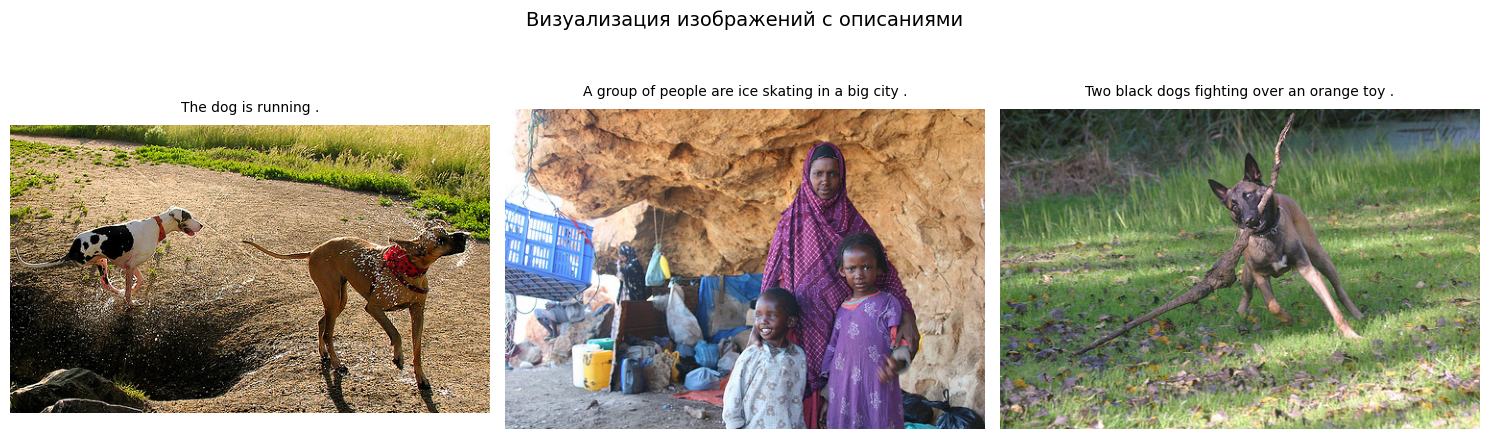

In [ ]:
# Директория с изображениями
IMAGES_DIR = 'test_images'

# Функция для отображения изображения с описанием
def display_image_with_description(image_path, query_text, ax):
    try:
        img = Image.open(image_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(query_text, fontsize=10, wrap=True, pad=10)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'Изображение не найдено:\n{image_path}',
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

# Основной код: отображение трёх изображений
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Цикл для итерации по первым трём строкам DataFrame
for idx, (index, row) in enumerate(check_results_df.iterrows()):
    if idx >= 3:
        break

    image_filename = row['image']
    query_text = row['query_text']
    image_path = os.path.join(DATA_PATH, IMAGES_DIR, image_filename)

    display_image_with_description(image_path, query_text, axes[idx])

    print(f"Изображение {idx + 1}: {image_filename}")
    print(f"Описание: {query_text}")
    print("-" * 50)

plt.tight_layout()
plt.suptitle('Визуализация изображений с описаниями', fontsize=14, y=1.02)
plt.show()

## 8. Выводы

В текущей работе была разработана демонстрационная модель поиска изображений по текстовому запросу.

Были выполнены следующие этапы:

- загрузка данных
- первоначальный и исследовательский анализ данных
- предобработка данных и подготовка их к обучению модели
- обучены несколько моделей и выбрана лучшая
- проведено тестирование модели на тестовом наборе данных
- соблюдены требования законодательства

Модель показала себя неоднозначно. Отдельные изображения довольно точно "попадают" в запрос, а другие соответствуют ему лишь частично. Возможно, если увеличить количество данных для обучения и детальней проработать архитектуру модели, результаты могут быть лучше.

Сама по себе идея выглядит вполне жизнеспособной и реализуемой.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Исследовательский анализ данных выполнен
- [x]  Проверены экспертные оценки и краудсорсинговые оценки
- [x]  Из датасета исключены те объекты, которые выходят за рамки юридических ограничений
- [x]  Изображения векторизованы
- [x]  Текстовые запросы векторизованы
- [x]  Данные корректно разбиты на тренировочную и тестовую выборки
- [x]  Предложена метрика качества работы модели
- [x]  Предложена модель схожести изображений и текстового запроса
- [x]  Модель обучена
- [x]  По итогам обучения модели сделаны выводы
- [x]  Проведено тестирование работы модели
- [x]  По итогам тестирования визуально сравнили качество поиска